# House Price Prediction Using Linear Regression in R

Beginner-friendly Google Colab notebook. **Runtime → Change runtime type → R** (if available). Upload `house_prices.csv` using the Files panel, then run cells in order.

**Goal:** Predict `Price` from `SquareFeet`, `Bedrooms`, `Bathrooms`, and `Age`.

## 1. Load the dataset

We load the CSV file and check its first rows and column types. Upload `house_prices.csv` to the Colab session before running this cell.

In [1]:
# Read the CSV file into R
house_data <- read.csv("house_prices.csv")

# Show the first 6 houses and check the column types
head(house_data)
str(house_data)

,SquareFeet,Bedrooms,Bathrooms,Age,Price
,<int>,<int>,<int>,<int>,<int>
1,1200,2,1,15,180000
2,1500,3,2,10,225000
3,1800,3,2,5,275000
4,2000,4,2,8,295000
5,2200,4,3,3,340000
6,1100,2,1,20,165000


'data.frame':	100 obs. of  5 variables:
 $ SquareFeet: int  1200 1500 1800 2000 2200 1100 1400 1600 1900 2100 ...
 $ Bedrooms  : int  2 3 3 4 4 2 3 3 4 4 ...
 $ Bathrooms : int  1 2 2 2 3 1 2 2 2 3 ...
 $ Age       : int  15 10 5 8 3 20 12 7 6 4 ...
 $ Price     : int  180000 225000 275000 295000 340000 165000 210000 245000 285000 325000 ...


## 2. Shuffle and split the data

We use 80 houses for training and 20 for testing. `set.seed(123)` makes the shuffle reproducible. The test houses are kept separate from training.

In [2]:
# Set a fixed seed so the random shuffle is reproducible
set.seed(123)

# Shuffle all rows, keeping every column
house_data <- house_data[sample(nrow(house_data)), ]

# Calculate the number of training rows (80%)
train_size <- floor(0.8 * nrow(house_data))

# Select training rows and the remaining testing rows
train_data <- house_data[1:train_size, ]
test_data <- house_data[(train_size + 1):nrow(house_data), ]

print(paste("Training houses:", nrow(train_data)))
print(paste("Testing houses:", nrow(test_data)))

[1] "Training houses: 80"
[1] "Testing houses: 20"


## 3. Train the linear regression model

`lm()` trains a linear regression model. **Price** is the target, and the four house measurements are inputs. `summary()` shows the fitted coefficients and other model statistics.

In [3]:
# Train a model to predict Price using four features
model <- lm(Price ~ SquareFeet + Bedrooms + Bathrooms + Age,
            data = train_data)

# Display the model summary and its coefficients
summary(model)
coef(model)


Call:
lm(formula = Price ~ SquareFeet + Bedrooms + Bathrooms + Age, 
    data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-13177.7  -4992.6    467.4   5365.4  14952.2 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -66214.192  15659.375  -4.228 6.57e-05 ***
SquareFeet     157.698      9.296  16.964  < 2e-16 ***
Bedrooms      5641.738   2913.270   1.937   0.0566 .  
Bathrooms    12532.348   2928.235   4.280 5.46e-05 ***
Age           1211.348    511.497   2.368   0.0205 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7259 on 75 degrees of freedom
Multiple R-squared:  0.9901,	Adjusted R-squared:  0.9895 
F-statistic:  1868 on 4 and 75 DF,  p-value: < 2.2e-16


(Intercept)  SquareFeet    Bedrooms   Bathrooms         Age 
 -66214.192     157.698    5641.738   12532.348    1211.348

## 4. Predict prices for test houses

`predict()` estimates prices for the 20 houses not used to train the model. We compare actual and predicted prices.

In [4]:
# Predict the prices of houses in the test set
predictions <- predict(model, newdata = test_data)

# Show actual prices next to predicted prices
comparison <- data.frame(
  Actual = test_data$Price,
  Predicted = round(predictions, 2)
)
print(comparison)

   Actual Predicted
59 217000  220550.9
48 362000  362231.8
24 390000  380489.3
45 212000  215454.4
81 372000  368539.7
68 186000  181624.9
88 166000  161604.3
98 184000  178471.0
44 162000  159661.7
10 325000  329960.9
56 303000  314754.7
11 175000  184413.2
55 273000  276362.0
37 358000  357135.2
2  225000  224436.1
28 425000  423349.9
74 222000  224070.5
35 238000  235840.6
52 430000  431234.8
1  180000  165009.4


## 5. Evaluate the predictions

**MAE** is the average absolute prediction error. **RMSE** penalizes larger errors more. **Test R²** measures how well predictions explain variation in test prices; it can be negative. These are regression metrics, so a confusion matrix is not appropriate.

In [5]:
# Find the difference between actual and predicted prices
errors <- test_data$Price - predictions

# Mean Absolute Error (average size of the errors)
mae <- mean(abs(errors))

# Root Mean Squared Error (penalizes large errors more)
rmse <- sqrt(mean(errors^2))

# R-squared calculated on the test set
r_squared <- 1 - sum(errors^2) /
  sum((test_data$Price - mean(test_data$Price))^2)

# Print evaluation results
print(paste("Test R-squared:", round(r_squared, 4)))
print(paste("Test MAE:", round(mae, 2)))
print(paste("Test RMSE:", round(rmse, 2)))

[1] "Test R-squared: 0.9956"
[1] "Test MAE: 4493.55"
[1] "Test RMSE: 5929.59"


## 6. Plot actual vs. predicted prices

Each dot represents one test house. The red diagonal line indicates a perfect prediction; dots closer to it represent smaller errors.

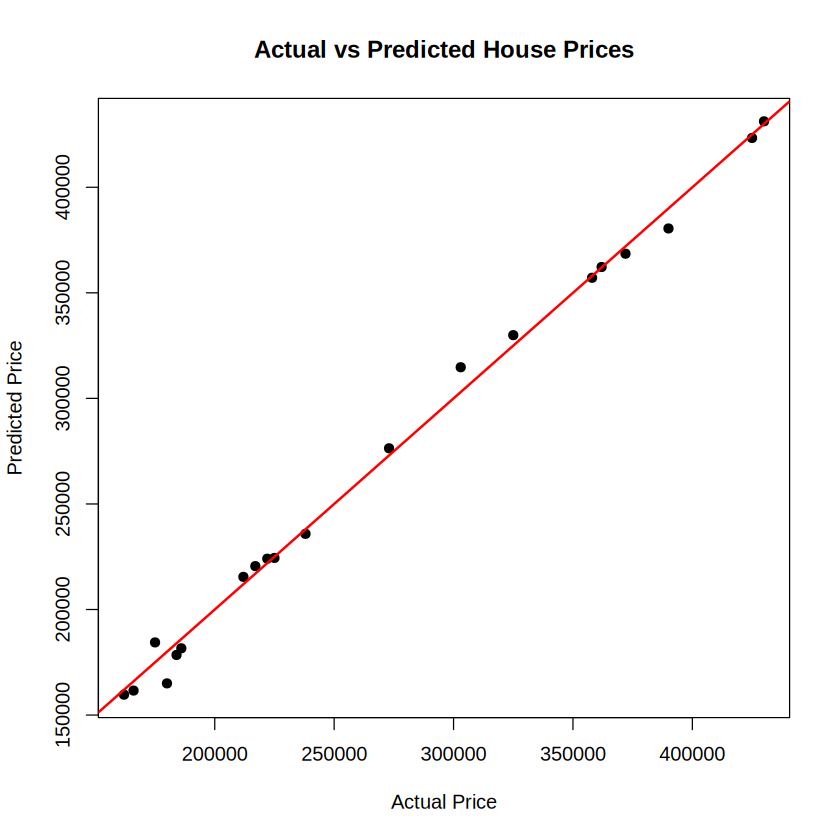

In [6]:
# Plot actual and predicted house prices
plot(test_data$Price, predictions,
     main = "Actual vs Predicted House Prices",
     xlab = "Actual Price",
     ylab = "Predicted Price",
     pch = 19)

# Draw the perfect-prediction line
abline(a = 0, b = 1, col = "red", lwd = 2)

## Optional: Predict the price of a new house

Change the values below to see how the model predicts a new house price.

In [7]:
# Create a new house with four known features
new_house <- data.frame(
  SquareFeet = 1600,
  Bedrooms = 3,
  Bathrooms = 2,
  Age = 8
)

# Predict its price
new_price <- predict(model, newdata = new_house)
print(paste("Predicted new house price:", round(new_price, 2)))

[1] "Predicted new house price: 237783.24"
